In [10]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

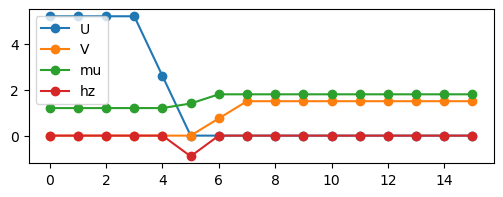

In [11]:
widthS = 5
widthF = 1
widthP = 10

X, Y = widthS+widthF+widthP, 200
lattice = Lattice(X, Y)
t = 1

muS = 1.2 * t
muP = 1.8 * t
muF = 1.4 * t

T = 0.001 * t

mu = np.zeros(lattice.X)
mu[:widthS] = muS
mu[widthS:widthS + widthF] = muF
mu[widthS + widthF:] = muP

hz0 = -0.9 * t
hz = np.zeros_like(mu)
hz[widthS:widthS + widthF] = hz0

U0 = 5.2 * t
U = U0 * np.ones(lattice.X)
U[widthS:] = 0
U[widthS-1] = U0/2

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)
V[:widthF+widthS] = 0
V[widthF+widthS] = V0/2

V_prime = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(hz, '-o', label='hz')

plt.legend()

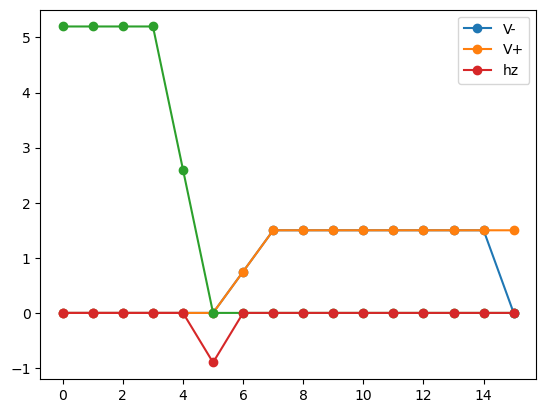

In [12]:
V_plus = np.r_[[0],V[1:]]
V_minus = np.r_[V[:-1], [0]]

plt.plot(V_minus, "-o", label="V-")
plt.plot(V_plus, "-o", label="V+")
plt.plot(U, "-o")
plt.plot(hz, '-o', label='hz')
plt.legend()

In [13]:
H = Hamiltonian(
    t, mu, lattice,
    U=U, V_prime=V_prime, g_t=V, g_s=V,
    F0_init=0.5, hz=hz,
    F_init=[0.1, -0.1, 0.1j, -0.1j],
)

d:\miniconda3\envs\master-venv\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\miniconda3\envs\master-venv\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


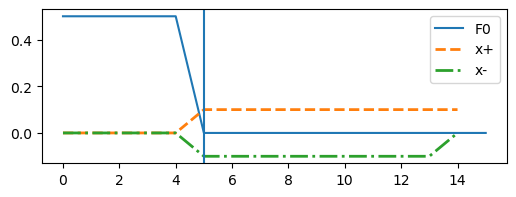

In [14]:
plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(H.F0, label="F0")
if V is not None:
    plt.plot(np.real(H.F_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.F_xmin), label="x-", linestyle='-.', lw=2)
    # plt.plot(np.imag(H.F_yplus), label="y+", linestyle='-', lw=2)
    # plt.plot(np.imag(H.F_ymin), label="y-", linestyle=':', lw=2)
if V_prime is not None:
    plt.plot(np.real(H.Fuu_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.Fuu_xmin), label="x-", linestyle='-.', lw=2)
    # plt.plot(np.imag(H.Fuu_yplus), label="y+", linestyle='-', lw=2)
    # plt.plot(np.imag(H.Fuu_ymin), label="y-", linestyle=':', lw=2)
plt.legend()
plt.axvline(widthS)

In [15]:
# Adjust to your actual bdg_sc output
F_swave, F_dwave, F_px, F_py = bdg_sc(
    H, maxiter=1000, temperature=T,
    rtol=1e-1, atol=1e-4
)

Converged after 37 iterations


In [16]:
F, Fuu, Fdd = H.get_correlations()

T=0.001t


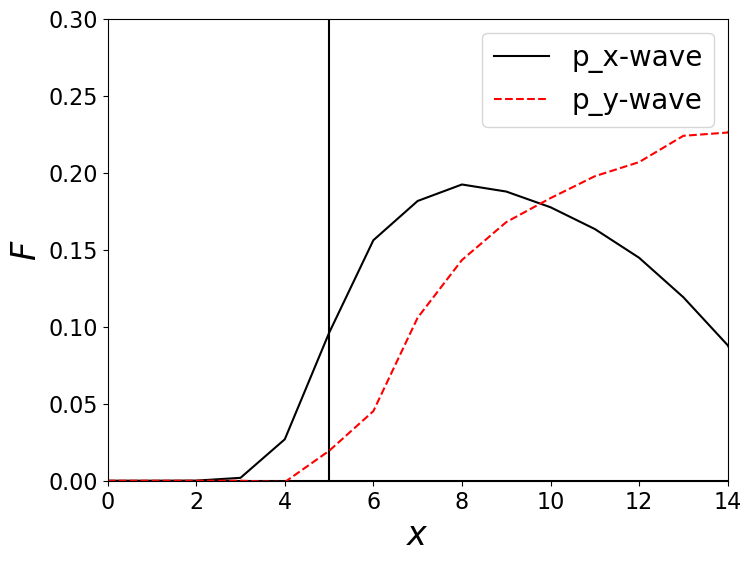

In [17]:
print(f"T={T}t")
x = np.arange(0, widthS + widthF + widthP)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.axhline(0, color = 'black')
axs.axvline(widthS, color='black', linestyle='-')
axs.plot(x, np.real(F_px), label="p_x-wave", color='black')
axs.plot(x, np.imag(F_py), "--", label="p_y-wave", color='red')
axs.set_xlabel(r"$x$", fontsize=24)
axs.set_ylabel(r"$F$", fontsize=24)

axs.set_xlim(0, 14)
axs.set_ylim(0, 0.3)
axs.legend(fontsize=20)
axs.tick_params(labelsize=16)
plt.savefig('../figures/NP.svg')
plt.show()

In [18]:
from scripts.utils import is_hermitian

print(is_hermitian(H.build_H_k(np.pi/4)))
print(is_hermitian(H.build_H_kindep()))
print(is_hermitian(H.build_H_k0()))

True
True
True
